In [1]:
import numpy as np 
from matplotlib import pyplot as plt 
import matplotlib as mpl

from pathlib import Path

import json

from datetime import datetime

from xaikd.approximators import ApproximatorMode, normalize_mode_name

In [2]:
ARTIFACT_DIR = Path("../../artifacts/2023-08-s10/experiments/clever-hans-")
OUTPUT_DIR = Path("../../figures/showcase1-cleverhans")

In [3]:
def load_data(contamination_level, model_name, layer, dataset, approximator_mode, compression_ratio, training_size, alpha, seed, basis_name, basis_mode="centered"):
    
    ldmse = alpha
    ldxent = 1-alpha
    with open(
        ARTIFACT_DIR
        / f"{dataset}-clv{contamination_level}-seed{seed}"
        / model_name
        / layer
        / "distillation" 
        / f"{normalize_mode_name(approximator_mode)}-comp{compression_ratio}-ldmse{ldmse}-ldxent{ldxent}" 
        / f"{basis_name}--{basis_mode}" 
        / "results.json",
        "r"
    ) as fh:
        
        return json.load(fh)

load_data(
    contamination_level=0.0,
    model_name="cifar100-resnet18-p1",
    layer="layer3",
    dataset="cifar100-people",
    approximator_mode=ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER,
    basis_name="identity",
    training_size=0.1,
    compression_ratio=10,
    alpha=0.5,
    seed=1
)

{'arr_metrics': {'train': [0.24799999594688416,
   0.25200000405311584,
   0.24799999594688416,
   0.2639999985694885,
   0.25600001215934753,
   0.2759999930858612,
   0.2919999957084656,
   0.30000001192092896,
   0.3199999928474426,
   0.3400000035762787,
   0.335999995470047,
   0.35600000619888306,
   0.3720000088214874,
   0.3799999952316284,
   0.36800000071525574,
   0.36800000071525574,
   0.3880000114440918,
   0.3799999952316284,
   0.4000000059604645,
   0.41200000047683716,
   0.40799999237060547,
   0.4359999895095825,
   0.4359999895095825,
   0.46799999475479126,
   0.4560000002384186,
   0.46399998664855957,
   0.47999998927116394,
   0.47200000286102295,
   0.46000000834465027,
   0.492000013589859,
   0.4880000054836273,
   0.5,
   0.4959999918937683,
   0.492000013589859,
   0.47999998927116394,
   0.4959999918937683,
   0.5040000081062317,
   0.5080000162124634,
   0.5199999809265137,
   0.5040000081062317,
   0.5120000243186951,
   0.5199999809265137,
   0.5279999

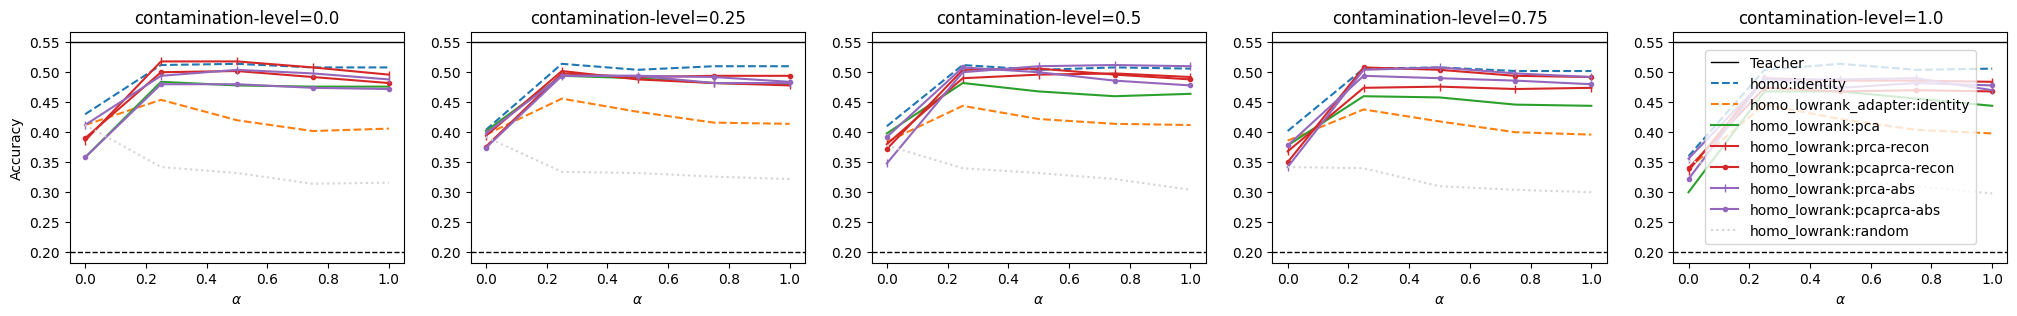

In [4]:
def marker(basis_name):
    if basis_name in ["prca-abs", "prca-recon"]:
        return "|"
    if "pcaprca" in basis_name:
        return "."
    else:
        return ""
    
def label(basis_name, approx_mode):
    
#     if approx_mode == ApproximatorMode.HOMOGENOUS:
#         return "Reinitialization"
#     elif approx_mode == ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER:
#         return "Lowrank with Adapter"
#     else:
#         return basis_name
    short_approx_mode = normalize_mode_name(approx_mode).replace("genous", "")
    
    return f"{short_approx_mode}:{basis_name}"
    
def ls(basis_name):
    if basis_name == "identity":
        return "--"
    elif "random" in basis_name:
        return ":"
    else:
        return "-"
    
def color(basis_name):
    if basis_name == "random":
        return "lightgray"
    elif "pcaprca" in basis_name:
        return plt.gca().lines[-1].get_color()
    else:
        return None
    
def viz():
    arr_alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
    model_name = "cifar100-resnet18-p1"
    layer = "layer3"
    dataset = "cifar100-people"
    seed = 1
    compression_ratio = 10
    
    training_size = 0.1
    contamination_levels = [0.0, 
                            0.25, 
                            0.5, 
                            0.75,
                            1.0]


    arr_approximator_basese = [ 
        (ApproximatorMode.HOMOGENOUS, 1.0, "identity"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER, compression_ratio, "identity"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "pca"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "prca-recon"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "pcaprca-recon"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "prca-abs"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "pcaprca-abs"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "random")
    ]

    ncols = len(contamination_levels)
    
    plt.figure(figsize=(5*ncols, 3))
    
    teacher_acc = None
    for cix, contamination_level in enumerate(contamination_levels):
        plt.subplot(1, ncols, cix+1)
        
        plt.title(f"contamination-level={contamination_level}")
        
        for aix, (approximator_mode, compr_ratio, basis_name) in enumerate(arr_approximator_basese):
            stats = []

            for alpha in arr_alphas:
                data = load_data(
                    contamination_level=contamination_level,
                    model_name=model_name,
                    layer=layer,
                    dataset=dataset,
                    approximator_mode=approximator_mode,
                    basis_name=basis_name,
                    training_size=training_size,
                    compression_ratio=compr_ratio,
                    alpha=alpha,
                    seed=seed
                )
        
                if teacher_acc is None:
                    teacher_acc = data["teacher_acc"]
                    
                else:
                    # sanity check
                    assert teacher_acc == data["teacher_acc"]
                
                if aix == 0 and alpha == arr_alphas[0]:
                    plt.axhline(teacher_acc, ls="-", lw=1, color="k", label=f"Teacher")

                metric = np.max(data["arr_metrics"]["val"])
                stats.append(metric)
#             print(f"[level={contamination_level}] basis_name={basis_name}: {stats[:2]}")
            plt.plot(
                arr_alphas, stats, 
                ls=ls(basis_name), 
                label=label(basis_name, approximator_mode), 
                marker=marker(basis_name),
                color=color(basis_name)
            )
            
            
        if cix == 0:
            plt.ylabel("Accuracy")
            
            
        plt.xlabel(r"$\alpha$")
        
        if cix == ncols - 1:
            plt.legend()
        
        plt.axhline(0.2, ls="--", lw=1, color="k")

viz()

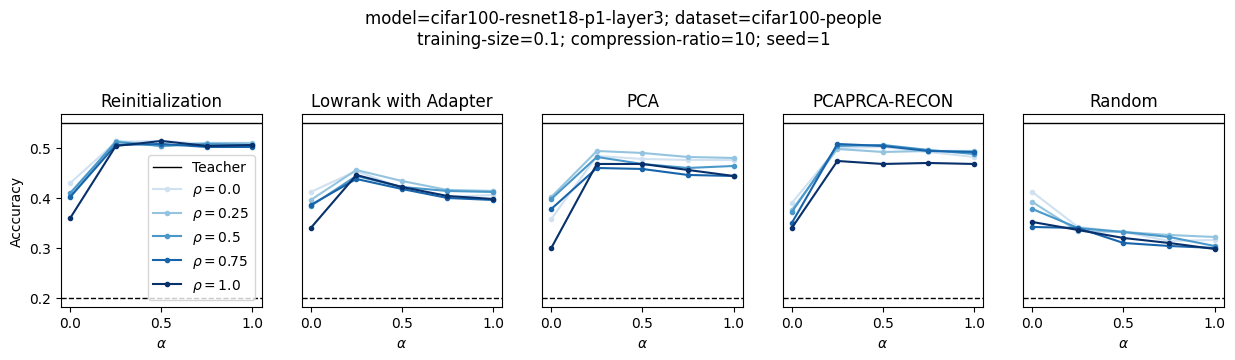

In [5]:
def label2(basis_name, approx_mode):
    
    if approx_mode == ApproximatorMode.HOMOGENOUS:
        return "Reinitialization"
    elif approx_mode == ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER:
        return "Lowrank with Adapter"
    elif basis_name == "random":
        return "Random"
    else:
        return basis_name.upper()
    
    
def viz_across_basis(training_size, should_save=True):
    arr_alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
    model_name = "cifar100-resnet18-p1"
    layer = "layer3"
    dataset = "cifar100-people"
    seed = 1
    compression_ratio = 10
    
    contamination_levels = [0.0, 0.25,  0.5,  0.75, 1.0]


    arr_approximator_basese = [ 
        (ApproximatorMode.HOMOGENOUS, 1.0, "identity"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK_ADAPTER, compression_ratio, "identity"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "pca"),
#         (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "prca-recon"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "pcaprca-recon"),
#         (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "prca-abs"),
#         (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "pcaprca-abs"),
        (ApproximatorMode.HOMOGENOUS_LOWRANK, compression_ratio, "random")
    ]

    ncols = len(arr_approximator_basese)
    
    colors = mpl.colormaps['Blues'](np.linspace(0.2, 1, len(contamination_levels)))


    plt.figure(figsize=(3*ncols, 2.5))
    plt.suptitle(
        "\n".join(
            [
                f"model={model_name}-{layer}; dataset={dataset}",
                f"training-size={training_size}; compression-ratio={compression_ratio}; seed={seed}"
            ]
        ),
        y=1.3
    )
    
    teacher_acc = None
    for aix, (approximator_mode, compr_ratio, basis_name) in enumerate(arr_approximator_basese):
        plt.subplot(1, ncols, aix+1)
        plt.title(label2(basis_name, approximator_mode))
        
        for cix, contamination_level in enumerate(contamination_levels):
            stats = []

            for alpha in arr_alphas:
                data = load_data(
                    contamination_level=contamination_level,
                    model_name=model_name,
                    layer=layer,
                    dataset=dataset,
                    approximator_mode=approximator_mode,
                    basis_name=basis_name,
                    training_size=training_size,
                    compression_ratio=compr_ratio,
                    alpha=alpha,
                    seed=seed
                )

                if teacher_acc is None:
                    teacher_acc = data["teacher_acc"]

                else:
                    # sanity check
                    assert teacher_acc == data["teacher_acc"]

                if cix == 0 and alpha == arr_alphas[0]:
                    plt.axhline(teacher_acc, ls="-", lw=1, color="k", label=f"Teacher")
                    plt.axhline(0.2, ls="--", lw=1, color="k")

                metric = np.max(data["arr_metrics"]["val"])
                stats.append(metric)

            plt.plot(
                arr_alphas, stats, 
                label=f"$\\rho={contamination_level}$",
                color=colors[cix],
                marker="."
            )
        plt.xlabel("$\\alpha$")
        if aix == 0:
            plt.legend()
            plt.ylabel("Acccuracy")
        else:
            plt.yticks([])
    
    if should_save:
        plt.savefig(
            OUTPUT_DIR / f"{dataset}--ts{training_size}.png",
            dpi=150, bbox_inches="tight"
        )
    
viz_across_basis(training_size=0.1)

In [6]:
print(f"Finished at {datetime.now()}")

Finished at 2023-08-08 06:40:16.316147
